In [11]:
import arviz as az
import cmdstanpy
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy.special import expit, logit
import seaborn as sns

## Simulating data
We are simulating attendance over fifteen weeks for three seminars (A, B, and C ) and for two semesters (W and S). We assume additive effects without an interaction. A-W: 15, B-W: 12, C-W: 13, A-S: 23, B-W: 20, C-W: 21

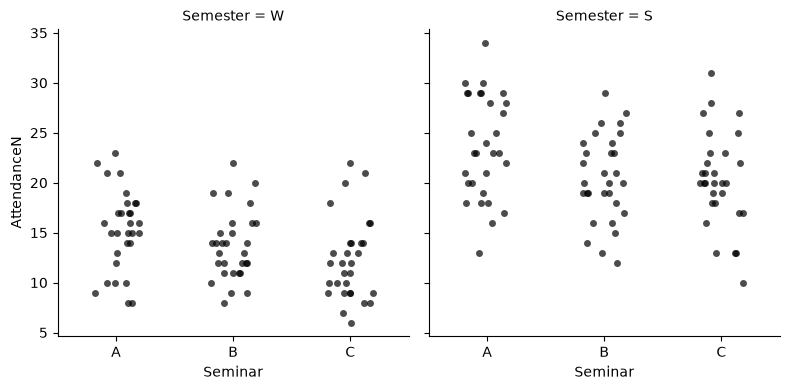

In [3]:
weeks_n = 30
np.random.seed(2077)

# Generate synthetic Poisson-distributed attendance data
example05_df = pd.DataFrame(
    {
        "Seminar": np.repeat(["A", "B", "C", "A", "B", "C"], weeks_n),
        "Semester": np.repeat(["W", "W", "W", "S", "S", "S"], weeks_n),
        "AttendanceN": np.concatenate(
            [
                np.random.poisson(lam=15, size=weeks_n),
                np.random.poisson(lam=12, size=weeks_n),
                np.random.poisson(lam=13, size=weeks_n),
                np.random.poisson(lam=23, size=weeks_n),
                np.random.poisson(lam=20, size=weeks_n),
                np.random.poisson(lam=21, size=weeks_n),
            ]
        ),
    }
)

# Convert to Categorical variables
example05_df["Seminar"] = pd.Categorical(
    example05_df["Seminar"], categories=["A", "B", "C"]
)
example05_df["Semester"] = pd.Categorical(
    example05_df["Semester"], categories=["W", "S"], ordered=True
)

# Plotting with FacetGrid (facet_wrap equivalent) and stripplot (geom_sina equivalent)
g = sns.FacetGrid(example05_df, col="Semester", height=4, aspect=1)
g.map_dataframe(sns.stripplot, x="Seminar", y="AttendanceN", jitter=0.2, color="black", alpha=0.7)

# Adjust plot formatting
g.set_axis_labels("Seminar", "AttendanceN")
g.set_titles(col_template="Semester = {col_name}")
plt.tight_layout()
plt.show()

## Model definitions

### Baseline
$$AttendanceN \sim Poisson(\lambda)$$
$$\lambda \sim LogNormal(2.5, 3)$$

### Seminar only

$$AttendanceN_i \sim Poisson(\lambda[Seminar_i])$$
$$\lambda[Seminar_i] \sim LogNormal(2.5, 3)$$

### Semester only

$$AttendanceN_i \sim Poisson(\lambda[Semester_i])$$
$$\lambda[Semester_i] \sim LogNormal(2.5, 3)$$

### Full model

$$AttendanceN_i \sim Poisson(\lambda_i)$$
$$log(\lambda_i) =  \alpha_{AW} + \beta_B\cdot IsB + \beta_C\cdot IsC + \beta_S\cdot IsSummer$$
$$\alpha_{AW} \sim Normal(log(15), 0.5)$$
$$\beta_B, \beta_C, \beta_S \sim Normal(0, 1)$$

### Interaction model

$$AttendanceN_i \sim Poisson(\lambda[Seminar_i, Semester_i])$$
$$\lambda[Seminar_i, Semester_i] \sim LogNormal(2.5, 3)$$

## Compiling all models

In [4]:
example05_modelnames = ["baseline", "seminar", "semester", "full", "interaction"]
example05_models = {amodel : cmdstanpy.CmdStanModel(stan_file=f"Stan/example05-{amodel}.stan")
                    for amodel in example05_modelnames}

## Preparing the data in Stan format

In [6]:
example05_standata = {
    "N": len(example05_df),
    "SeminarsN": len(example05_df["Seminar"].cat.categories),
    "SemestersN": len(example05_df["Semester"].cat.categories),
   
    "AttendanceN": example05_df["AttendanceN"].to_numpy(),
    "Seminar": example05_df["Seminar"].cat.codes.to_numpy() + 1,
    "Semester": example05_df["Semester"].cat.codes.to_numpy() + 1
}

## Sampling the model

In [17]:
example05_fits = {}
example05_loos = {}
for amodel in example05_modelnames:
    example05_fits[amodel] = example05_models[amodel].sample(
        data=example05_standata,
        chains=4,
        parallel_chains=os.cpu_count())
    # Convert fit to ArviZ InferenceData (extracts log-likelihood automatically)
    idata = az.from_cmdstanpy(example05_fits[amodel], log_likelihood="log_lik")
    # Compute PSIS-LOO
    example05_loos[amodel] = az.loo(idata)

15:45:13 - cmdstanpy - INFO - Requested 8 parallel_chains but only 4 required, will run all chains in parallel.
15:45:13 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

...

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

15:45:21 - cmdstanpy - INFO - CmdStan done processing.


## Compare models via LOO information criterion

In [19]:
# Model comparison (equivalent to loo::loo_compare)
loo_comp = az.compare(example05_loos)
print("LOO Comparison:")
print(loo_comp)

# Compute stacking model weights (equivalent to loo::loo_model_weights)
model_weights = az.loc_weights if hasattr(az, "loc_weights") else loo_comp["weight"]
print("\nLOO Model Weights:")
print(loo_comp[["weight"]])

LOO Comparison:
             rank  elpd_diff   dse  p_worse        diag_diff diag_elpd    p  \
full            0        0.0   0.0      NaN                             4.2   
interaction     1       -2.0   1.2     0.91  |elpd_diff| < 4            6.2   
semester        2       -7.0   4.6     0.94                             2.2   
seminar         3      -80.0  13.0     1.00                             5.5   
baseline        4      -80.0  14.0     1.00                             2.0   

              elpd    se  weight  
full        -520.0   9.1    0.86  
interaction -520.0   9.3    0.00  
semester    -520.0   9.5    0.11  
seminar     -590.0  14.0    0.00  
baseline    -600.0  15.0    0.03  

LOO Model Weights:
             weight
full           0.86
interaction    0.00
semester       0.11
seminar        0.00
baseline       0.03
